## **ĐỀ BÀI & NHIỆM VỤ:**

Bạn đang đóng vai trò là một Chuyên viên Phân tích Dữ liệu (Data Analyst) cho một chuỗi cửa hàng mỹ phẩm trực tuyến.
> Giám đốc Marketing nhận thấy khách hàng thường mua nhiều sản phẩm cùng lúc nhưng hệ thống gợi ý hiện tại chưa hiệu quả.<br> Nhiệm vụ của bạn là **phân tích dữ liệu lịch sử giao dịch để tìm ra các "Combo nhóm hàng" tiềm năng nhất**, từ đó đề xuất chiến lược sắp xếp gian hàng và khuyến mãi.



---


Trả lời được các câu hỏi sau:
* Combo nào có sức mạnh liên kết lớn nhất? Có sự xuất hiện của các nhóm hàng đặc thù nào?
* Giải thích tâm lý khách hàng đằng sau các combo đó (Tại sao họ mua A lại thường mua kèm B?).
* Đưa ra đề xuất.



### **1. Import thư viện & dữ liệu**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')

In [2]:
import sys
PATH = '/content/drive/MyDrive/BT-XomDA/my_modules'
if not PATH in sys.path:
    sys.path.append(PATH)

#### __init.

In [3]:
import re

def check_dataframe_boxplot(df, show_head=True, plot_boxplots=True):
    """Thực hiện kiểm tra tổng thể một DataFrame:
    1. Metadata (df.info())
    2. Trùng lặp (df.duplicated().sum())
    3. Dữ liệu trống (df.isna().sum())
    4. Thống kê mô tả (df.describe().T) + thống kê outliers dựa trên IQR + thống kê missing values
    5. Xem trước dữ liệu (df.head())

    **df: dataframe cần kiểm tra
    **show_head: bool, default: True. Hiển thị 5 dòng đầu tiên
    **plot_boxplots: bool, default: True. Vẽ box plot cho từng cột số (numeric) trong df
    """
    print("=" * 65)
    print("1. METADATA CỦA DỮ LIỆU")
    print("=" * 65)
    df.info()
    print("\n")

    print("=" * 65)
    print("2. KIỂM TRA DỮ LIỆU TRÙNG LẶP")
    print("=" * 65)
    dup_count = df.duplicated().sum()
    dup_ratio = (dup_count / len(df)) * 100 if len(df) > 0 else 0
    print(f"- Số dòng bị trùng lặp: {dup_count:,} ({dup_ratio:.2f}%)")
    print("\n")

    print("=" * 65)
    print("3. KIỂM TRA DỮ LIỆU TRỐNG (MISSING VALUES)")
    print("=" * 65)
    null_count = df.isna().sum()
    null_ratio = (df.isna().sum() / len(df)) * 100 if len(df) > 0 else 0

    missing_df = pd.DataFrame(
        {
            "Kiểu dữ liệu": df.dtypes,
            "Số lượng trống": null_count,
            "Tỷ lệ trống (%)": null_ratio.round(2),
        }
    )

    missing_only = missing_df[missing_df["Số lượng trống"] > 0]
    if not missing_only.empty:
        print(missing_only.to_string())
    else:
        print("-> Không có dữ liệu trống trong bất kỳ cột nào.")
    print("\n")

    print("=" * 65)
    print("4. THỐNG KÊ MÔ TẢ & PHÁT HIỆN OUTLIERS (BOX PLOT)")
    print("=" * 65)
    num_cols = df.select_dtypes(include=[np.number]).columns.to_list()
    num_cols = [col for col in num_cols
                if not re.search(r'(^id$|.*id$)',col.lower())]

    n_cols = len(num_cols)

    if n_cols > 0:
        # Bảng thống kê mô tả căn bản
        desc = df[num_cols].describe().T

        # Tính toán số lượng Outlier dựa trên quy tắc IQR (Q1 - 1.5*IQR đến Q3 + 1.5*IQR)
        outlier_counts = {}
        for col in num_cols:
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

            outlier_counts[col] = (((df[col] < lower) | (df[col] > upper)).sum())

        desc["outliers_iqr"] = pd.Series(outlier_counts)
        desc["outliers_iqr_ratio"] = (desc["outliers_iqr"] / len(df)) * 100
        desc['missing'] = df[num_cols].isna().sum()
        desc['missing_ratio'] = (df[num_cols].isna().mean() * 100).round(2)
        print(desc.round(2).to_string())
        print("\n")

        # Vẽ Box Plot cho từng cột số
        if plot_boxplots:
            # Tự động tính toán số hàng và số cột cho đồ thị (tối đa 3 cột mỗi hàng)
            ncols_plot = min(n_cols, 3)
            nrows_plot = (n_cols + ncols_plot - 1) // ncols_plot

            fig, axes = plt.subplots(
                nrows=nrows_plot,
                ncols=ncols_plot,
                figsize=(5 * ncols_plot, 4 * nrows_plot),
            )

            # Chuyển axes thành mảng 1D để dễ lặp qua
            axes = np.array(axes).reshape(-1)

            sns.set_style('dark')
            for idx, col in enumerate(num_cols):
              sns.boxplot(y=df[col], ax=axes[idx], color="#3182bd")
              axes[idx].set_title(
                    f"Boxplot: {col}", fontsize=11, fontweight="bold"
                )
              axes[idx].set_ylabel("")
              axes[idx].grid(True, linestyle="--", alpha=0.5)

            # Ẩn các khung đồ thị dư thừa nếu có
            for idx in range(n_cols, len(axes)):
                fig.delaxes(axes[idx])

            plt.tight_layout()
            plt.show()
    else:
        print("-> Không có cột dữ liệu dạng số trong DataFrame.")
    print("\n")

    # Xem trước 5 dòng đầu tiên
    if show_head:
        print("=" * 65)
        print("5. XEM TRƯỚC 5 DÒNG ĐẦU TIÊN")
        print("=" * 65)
        print(df.head().to_string())
        print("\n")

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# import dataset

sales = pd.read_csv('/content/drive/MyDrive/BT-XomDA/B7-BTVN/EcomSales.csv')
product = pd.read_csv('/content/drive/MyDrive/BT-XomDA/B7-BTVN/Product.csv')
customer = pd.read_csv('/content/drive/MyDrive/BT-XomDA/B7-BTVN/Customer.csv')
region = pd.read_csv('/content/drive/MyDrive/BT-XomDA/B7-BTVN/Region.csv')

### **2. Check dataframe**

In [ ]:
df_table = {
    'SALES': sales,
    'PRODUCT': product,
    'CUSTOMER': customer,
    'REGION': region
}

for table_name, df in df_table.items():
    print(f'KIỂM TRA DỮ LIỆU BẢNG {table_name}')
    print(check_dataframe_boxplot(df, show_head=True))

#### **Tổng hợp lỗi & bất thường**


*   Lỗi dtype: dtype của `OrderDate` - bảng `Sales` và `BirthDate` - bảng `customer` đang là object -> cần phải chuyển sang dạng datetime64[ns]
*   Lỗi giá trị trống (missing values) & giá trị lặp (duplicated values): không có.

In [7]:
sales['OrderDate'] = pd.to_datetime(sales['OrderDate'])
customer['BirthDate'] = pd.to_datetime(customer['BirthDate'])

### **3. Phân tích MBA ở cấp độ SKU**

In [8]:
# xem số lượng sản phẩm trong từng category và sub-category
product.groupby(by=['Category', 'Subcategory'], observed=True)['ProductCode'].nunique()

Category              Subcategory                 
Body care             Body soaps and washes           1133
                      Nail care products              2386
                      bath oils, bubbles and soaks    1474
                      body moisturizers               1551
                      face masks and exfoliators      1498
                      hand creams                     1577
                      vitamins and supplements        1929
Face care             face moisturizing products      1885
Hair care             hair colors and toners          1811
                      shampoos and conditioners       2259
Home and Accessories  Accessories                     1797
                      brushes and applicators         1913
                      candles, sprays, diffusers      1464
                      fragrances                       738
Make up               Eye shadows and pencils         2178
                      Lipsticks                       1234
                      foundations and concealers      1529
Name: ProductCode, dtype: int64

In [9]:
# merge tên product vào mỗi order thay vì chỉ biết ProductCode

df = pd.merge(sales[['OrderID','ProductCode']],
              product[['ProductCode', 'Product', 'Subcategory']],
              on='ProductCode', how='inner')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51288 entries, 0 to 51287
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   OrderID      51288 non-null  object
 1   ProductCode  51288 non-null  object
 2   Product      51288 non-null  object
 3   Subcategory  51288 non-null  object
dtypes: object(4)
memory usage: 1.6+ MB


In [10]:
# Sửa lỗi logic: Dùng set thay vì list để loại bỏ trùng lặp Subcategory trong cùng 1 OrderID
# Điều này giúp TransactionEncoder phản ánh đúng sự hiện diện của nhóm hàng thay vì số lượng SKU
basket = df.groupby(by=['OrderID'])['Product'].apply(set).reset_index()
basket = basket['Product'].to_list()

In [11]:
# xem 5 giao dịch đầu
basket[:5]

[{'Gold Whisper Brooch', 'Tata Harper Smoothing Body Scrub'},
 {"L'Oréal Paris EverPure Sulfate-Free Moisture Conditioner",
  'Schwarzkopf Live Intense Color - Mystic Violet'},
 {"Clairol Nice'n Easy Permanent Hair Color - Light Warm Brown",
  'Sephora Collection PRO Small Stippling Brush #42'},
 {'Anastasia Beverly Hills Brow Definer Soft Brown',
  'Anastasia Beverly Hills Norvina Eyeshadow Palette Base Cream Matte',
  'Aveeno Positively Radiant Targeted Tone Corrector',
  'China Glaze Nail Lacquer Lemon Fizz Soft Yellow',
  'Urban Decay Eyeshadow Flash Bright Purple',
  'Urban Decay Eyeshadow Half Baked Golden Bronze'},
 {'Gold Bond Ultimate Strength & Resilience Hand Cream'}]

In [12]:
# chuyển đơn hàng thành One-hot format

te = TransactionEncoder()
te_ary = te.fit(basket).transform(basket)
df_basket = pd.DataFrame(te_ary, columns=te.columns_)
df_basket.head()

,Acqua di Parma Blu Mediterraneo Arancia di Capri Bath & Shower Gel,Aesop Geranium Leaf Hydrating Body Treatment,Aesop Petitgrain Reviving Body Gel,Aesop Rind Concentrate Body Balm,Ahava Dead Sea Mineral Bath Salts,Ahava Dead Sea Osmoter™ Concentrate Even Tone Serum,Ahava Mineral Bath Salts,Ahava Mineral Shower Gel,Amethyst Blaze Bracelet,Amethyst Bliss Bracelet,...,Zoya Nail Polish Remy Deep Teal with Glitter,Zoya Nail Polish Robyn Bright Blue,Zoya Nail Polish Rue Soft Blush,Zoya Nail Polish Sooki Bright Red,Zoya Nail Polish Spencer Camel Beige,Zoya Nail Polish Storm Black with Holographic Glitter,Zoya Nail Polish Talia Bright Turquoise,Zoya Nail Polish Trixie Metallic Silver,Zoya Nail Polish Willa Glossy Black,Zoya Nail Polish Yara Olive Green with Gold Shimmer
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


> Với số lượng 3576 sản phẩm trong sàn TMĐT, chọn `min_support = 0.001` => các frequent item được chọn sẽ xuất hiện trong ít nhất 0.1% đơn hàng.

In [13]:
frequent_itemsets = apriori(df_basket,
                            min_support=0.001,
                            use_colnames=True,
                            max_len=None)
frequent_itemsets.sort_values(by='support', ascending=False)
frequent_itemsets.head()

,support,itemsets
0,0.001555,(Anastasia Beverly Hills Brow Definer Auburn)
1,0.001516,(Anastasia Beverly Hills Brow Definer Dark Brown)
2,0.001166,(Anastasia Beverly Hills Brow Definer Granite)
3,0.001671,(Anastasia Beverly Hills Brow Definer Soft Brown)
4,0.001166,(Anastasia Beverly Hills Brow Wiz Ebony)


In [14]:
print(f'Số itemsets có support >= 0.001 là {len(frequent_itemsets)}')

Số itemsets có support >= 0.001 là 538


In [15]:
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets['length'].value_counts()

,count
length,
1,538


#### **Kết luận**

* Khi phân tích MBA ở cấp độ SKU, có 578 itemsets ở ngưỡng min_support = 0.001 nhưng tất cả đều là itemsets chỉ có 1 sản phẩm. Và do đó, không thể tiếp tục lọc các rule confidence và lift.
* Đối với ngành mỹ phẩm, số lượng SKU rất nhiều (trong dataset trên có khoảng 20,000 SKU) và bị phân mảnh bởi brand, màu sắc, dung tích, mùi hương,...<br>
| Top 5 frequent items|
|---|
| Anastasia Beverly Hills Brow Definer Aubur |
| Anastasia Beverly Hills Brow Definer Dark Brown |
| Anastasia Beverly Hills Brow Definer Granite |
| Anastasia Beverly Hills Brow Definer Soft Brown|
| Anastasia Beverly Hills Brow Wiz Ebony |

  => 4/5 sản phẩm cùng brand, cùng loại sản phẩm và chỉ khác nhau về màu sắc.
* Như vậy, phân tích MBA ở cấp độ SKU không phải là phương án tối ưu nhất cho dataset này. Một cách tiếp cận tối ưu hơn là phân tích ở cấp độ Subcategory, phản ánh được các loại nhu cầu (dưỡng ẩm cho da, tẩy tế bào da chết, chăm sóc tóc,...) phổ biến và có mối liên kết với nhau mạnh.


### **4. Phân tích MBA ở cấp độ Subcategory**

In [16]:
# Tương tự cho cấp độ Subcategory để đảm bảo tính chính xác của tần suất xuất hiện
subcat_basket = df.groupby(by='OrderID')['Subcategory'].apply(set).reset_index()
subcat_basket = subcat_basket['Subcategory'].to_list()

In [17]:
subcat_basket[:5]

[{'face masks and exfoliators', 'hand creams'},
 {'Nail care products', 'candles, sprays, diffusers'},
 {'hand creams', 'shampoos and conditioners'},
 {'Nail care products',
  'hair colors and toners',
  'shampoos and conditioners',
  'vitamins and supplements'},
 {'Nail care products'}]

In [18]:
# chuyển thành one-hot array
subcat_te = TransactionEncoder()
subcat_te_array = subcat_te.fit(subcat_basket).transform(subcat_basket)

# chuyển array thành dataframe

df_subcat_basket = pd.DataFrame(subcat_te_array, columns = subcat_te.columns_)
df_subcat_basket.head()

,Accessories,Body soaps and washes,Eye shadows and pencils,Lipsticks,Nail care products,"bath oils, bubbles and soaks",body moisturizers,brushes and applicators,"candles, sprays, diffusers",face masks and exfoliators,face moisturizing products,foundations and concealers,fragrances,hair colors and toners,hand creams,shampoos and conditioners,vitamins and supplements
0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
1,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,True
4,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


In [19]:
min_support = 0.001

In [20]:
# chạy Apriori với ngưỡng min_support = 0.001
frequent_subcat = apriori(df_subcat_basket,
                          min_support=min_support,
                          use_colnames=True,
                          max_len=3)

print(f'Tìm được {len(frequent_subcat)} itemsets có support >= {min_support}')
print('\nTop 5 itemsets có support cao nhất:')
print(frequent_subcat.nlargest(5, columns='support'))

Tìm được 582 itemsets có support >= 0.001

Top 5 itemsets có support cao nhất:
     support                        itemsets
4   0.199122            (Nail care products)
15  0.160836     (shampoos and conditioners)
5   0.147582  (bath oils, bubbles and soaks)
14  0.146883                   (hand creams)
6   0.143812             (body moisturizers)


In [21]:
frequent_subcat['length'] = frequent_subcat['itemsets'].apply(len)
frequent_subcat['length'].value_counts()

,count
length,
3,429
2,136
1,17


In [22]:
# lọc lift > 1

rules = association_rules(frequent_subcat,
                               metric='lift',
                               min_threshold=1)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Accessories),"(bath oils, bubbles and soaks)",0.094372,0.147582,0.014537,0.154036,1.043730,1.0,0.000609,1.007629,0.046264,0.063921,0.007571,0.126268
1,"(bath oils, bubbles and soaks)",(Accessories),0.147582,0.094372,0.014537,0.098499,1.043730,1.0,0.000609,1.004578,0.049152,0.063921,0.004557,0.126268
2,(Accessories),(fragrances),0.094372,0.023282,0.002215,0.023476,1.008336,1.0,0.000018,1.000199,0.009129,0.019192,0.000199,0.059317
3,(fragrances),(Accessories),0.023282,0.094372,0.002215,0.095159,1.008336,1.0,0.000018,1.000869,0.008464,0.019192,0.000869,0.059317
4,(Nail care products),(Lipsticks),0.199122,0.041939,0.008590,0.043139,1.028614,1.0,0.000239,1.001254,0.034735,0.036950,0.001253,0.123979


In [23]:
# lọc rules: lift >= 1.2 và confidence >= 0.1
top_rules = rules[(rules['lift']>= 1.2) & (rules['confidence']>= 0.1)]
top_rules = top_rules.iloc[:,:9].sort_values(by='lift', ascending=False).reset_index(drop=True)
top_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage
0,"(Accessories, candles, sprays, diffusers)",(hair colors and toners),0.006608,0.094372,0.001205,0.182353,1.932280,1.0,0.000581
1,"(candles, sprays, diffusers, shampoos and cond...",(hair colors and toners),0.011816,0.094372,0.002138,0.180921,1.917107,1.0,0.001023
2,"(shampoos and conditioners, Lipsticks)",(face moisturizing products),0.006646,0.115866,0.001438,0.216374,1.867453,1.0,0.000668
3,"(face masks and exfoliators, Lipsticks)",(shampoos and conditioners),0.003654,0.160836,0.001088,0.297872,1.852020,1.0,0.000501
4,"(face masks and exfoliators, Body soaps and wa...",(Accessories),0.007152,0.094372,0.001244,0.173913,1.842848,1.0,0.000569
5,"(hair colors and toners, shampoos and conditio...","(candles, sprays, diffusers)",0.014692,0.079796,0.002138,0.145503,1.823425,1.0,0.000965
6,"(candles, sprays, diffusers, bath oils, bubble...",(face masks and exfoliators),0.011039,0.113495,0.002254,0.204225,1.799421,1.0,0.001002
7,"(Accessories, brushes and applicators)",(hair colors and toners),0.008706,0.094372,0.001477,0.169643,1.797599,1.0,0.000655
8,"(foundations and concealers, Lipsticks)",(Nail care products),0.003382,0.199122,0.001205,0.356322,1.789469,1.0,0.000532
9,"(face masks and exfoliators, candles, sprays, ...","(bath oils, bubbles and soaks)",0.008551,0.147582,0.002254,0.263636,1.786367,1.0,0.000992


In [24]:
top_rules.describe()

,antecedent support,consequent support,support,confidence,lift,representativity,leverage
count,944.000000,944.000000,944.000000,944.000000,944.000000,944.0,944.000000
mean,0.013545,0.126255,0.002294,0.174570,1.387614,1.0,0.000621
std,0.005313,0.032801,0.000956,0.046661,0.137120,0.0,0.000288
min,0.002954,0.070157,0.001011,0.100304,1.200371,1.0,0.000182
25%,0.009600,0.094644,0.001555,0.138972,1.280593,1.0,0.000396
50%,0.012477,0.123406,0.002099,0.169222,1.359371,1.0,0.000568
75%,0.017102,0.146883,0.002837,0.202490,1.469423,1.0,0.000783
max,0.027830,0.199122,0.005480,0.356322,1.932280,1.0,0.001841


In [25]:
# with open('top_rules.csv', 'wb') as f:
#     top_rules.to_csv(f)

### **5. Đọc insights từ các cặp sản phẩm có liên kết mạnh nhất**

In [26]:
# chuyển tên item thành string => ghép thành tên combo
top_rules['antecedents_str'] = top_rules['antecedents'].apply(lambda x: '/ '.join(list(x))).astype('str')
top_rules['consequents_str'] = top_rules['consequents'].apply(lambda x: '/ '.join(list(x))).astype('str')

top_rules['combo_str'] = top_rules['antecedents_str'] + ' + ' + top_rules['consequents_str']
top_rules = top_rules.drop(columns=['representativity'])

In [27]:
# lấy top 10 combo theo lift
top_10_lift = top_rules.nlargest(10, columns='lift').reset_index(drop=True)
top_10_lift

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,antecedents_str,consequents_str,combo_str
0,"(Accessories, candles, sprays, diffusers)",(hair colors and toners),0.006608,0.094372,0.001205,0.182353,1.932280,0.000581,"Accessories/ candles, sprays, diffusers",hair colors and toners,"Accessories/ candles, sprays, diffusers + hair..."
1,"(candles, sprays, diffusers, shampoos and cond...",(hair colors and toners),0.011816,0.094372,0.002138,0.180921,1.917107,0.001023,"candles, sprays, diffusers/ shampoos and condi...",hair colors and toners,"candles, sprays, diffusers/ shampoos and condi..."
2,"(shampoos and conditioners, Lipsticks)",(face moisturizing products),0.006646,0.115866,0.001438,0.216374,1.867453,0.000668,shampoos and conditioners/ Lipsticks,face moisturizing products,shampoos and conditioners/ Lipsticks + face mo...
3,"(face masks and exfoliators, Lipsticks)",(shampoos and conditioners),0.003654,0.160836,0.001088,0.297872,1.852020,0.000501,face masks and exfoliators/ Lipsticks,shampoos and conditioners,face masks and exfoliators/ Lipsticks + shampo...
4,"(face masks and exfoliators, Body soaps and wa...",(Accessories),0.007152,0.094372,0.001244,0.173913,1.842848,0.000569,face masks and exfoliators/ Body soaps and washes,Accessories,face masks and exfoliators/ Body soaps and was...
5,"(hair colors and toners, shampoos and conditio...","(candles, sprays, diffusers)",0.014692,0.079796,0.002138,0.145503,1.823425,0.000965,hair colors and toners/ shampoos and conditioners,"candles, sprays, diffusers",hair colors and toners/ shampoos and condition...
6,"(candles, sprays, diffusers, bath oils, bubble...",(face masks and exfoliators),0.011039,0.113495,0.002254,0.204225,1.799421,0.001002,"candles, sprays, diffusers/ bath oils, bubbles...",face masks and exfoliators,"candles, sprays, diffusers/ bath oils, bubbles..."
7,"(Accessories, brushes and applicators)",(hair colors and toners),0.008706,0.094372,0.001477,0.169643,1.797599,0.000655,Accessories/ brushes and applicators,hair colors and toners,Accessories/ brushes and applicators + hair co...
8,"(foundations and concealers, Lipsticks)",(Nail care products),0.003382,0.199122,0.001205,0.356322,1.789469,0.000532,foundations and concealers/ Lipsticks,Nail care products,foundations and concealers/ Lipsticks + Nail c...
9,"(face masks and exfoliators, candles, sprays, ...","(bath oils, bubbles and soaks)",0.008551,0.147582,0.002254,0.263636,1.786367,0.000992,"face masks and exfoliators/ candles, sprays, d...","bath oils, bubbles and soaks","face masks and exfoliators/ candles, sprays, d..."


In [28]:
# with open('top_10_lift.csv', 'wb') as f:
#     top_10_lift.to_csv(f)

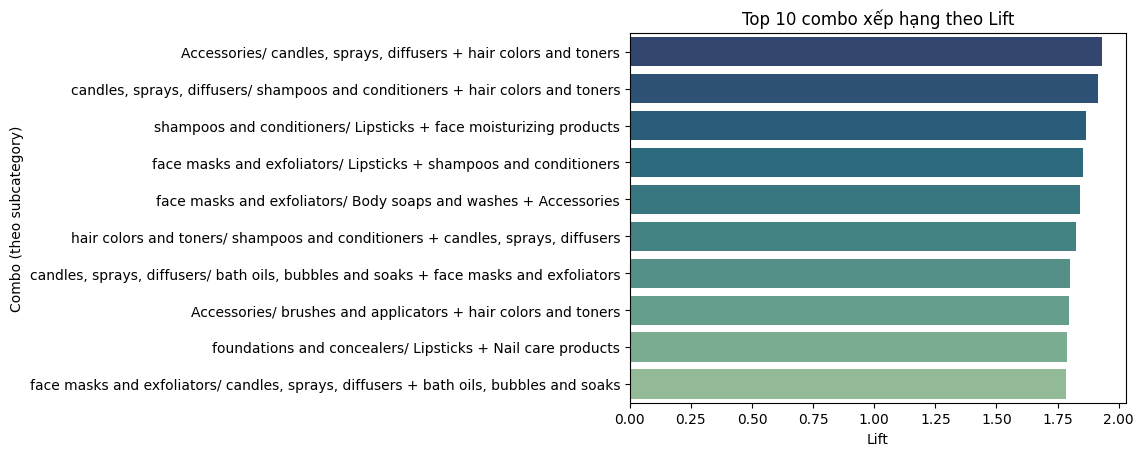

In [29]:
# trực quan hóa thành biểu đồ bar ngang

sns.barplot(data=top_10_lift, y='combo_str', x ='lift', hue='combo_str', palette='crest_r')
plt.xlabel('Lift')
plt.ylabel('Combo (theo subcategory)')
plt.title('Top 10 combo xếp hạng theo Lift')
plt.show()

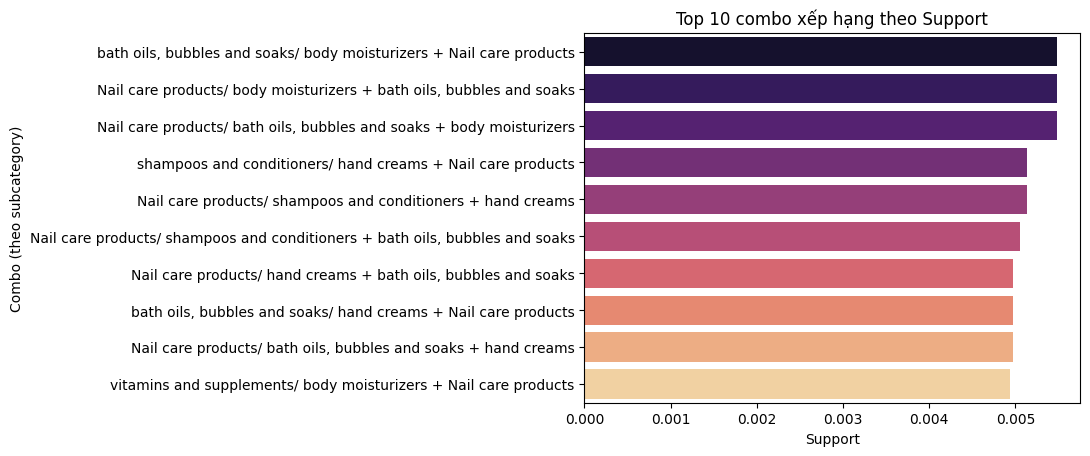

In [30]:
sns.barplot(data=top_rules.nlargest(10,'support'),
            y='combo_str',
            x ='support',
            hue='combo_str',
            palette='magma')
plt.xlabel('Support')
plt.ylabel('Combo (theo subcategory)')
plt.title('Top 10 combo xếp hạng theo Support')
plt.show()

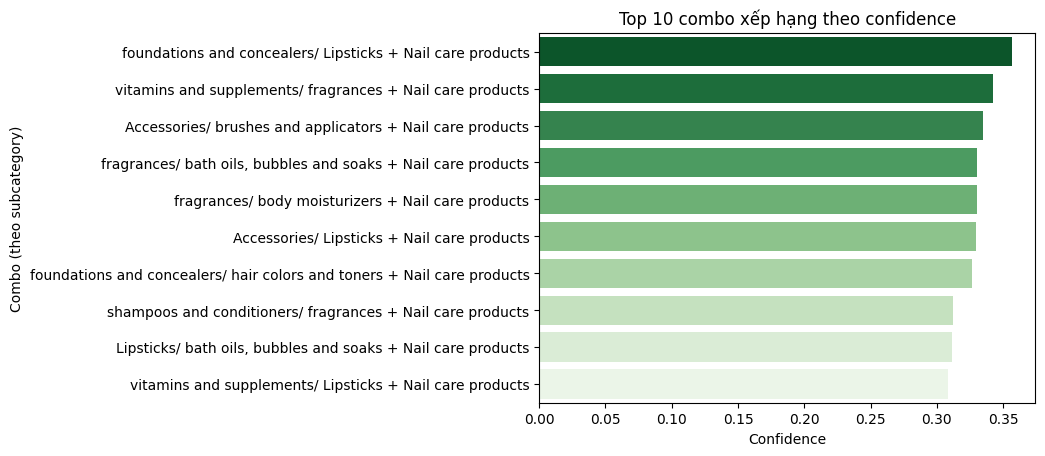

In [31]:
sns.barplot(data=top_rules.nlargest(10,'confidence'),
            y='combo_str',
            x ='confidence',
            hue='combo_str',
            palette='Greens_r')
plt.xlabel('Confidence')
plt.ylabel('Combo (theo subcategory)')
plt.title('Top 10 combo xếp hạng theo confidence')
plt.show()

#### **Insights đọc từ cả 3 biểu đồ**
* **Nail care products** là nhóm có độ phổ biến cao nhất, với `support = 20% tổng số đơn hàng`. Vì vậy, nhóm sản phẩm này xuất hiện trong toàn bộ top combo confidence và support không chỉ do liên kết mua kèm, mà còn do độ phổ biến cao.
* **Top 10 combo phổ biến nhất:** Các lựa chọn phổ biến tập trung vào chăm sóc tay, móng và cơ thể, gồm bath oils, body moisturizers, hand creams và shampoos and conditioners.
* **Top 10 combo theo confidence:** Khi khách đã mua sản phẩm trang điểm, phụ kiện hoặc chăm sóc cơ thể, xác suất lựa chọn tiếp theo là Nail care products đạt khoảng 31%–36%. Tuy nhiên, cần lưu ý baseline của nail care đã đạt 20% nên không chắc khả năng mua sản phẩm này sẽ tăng khả năng mua sản phẩm còn lại.
* **Top 10 combo trong nhóm có liên kết mạnh nhất** với nhau có sự xuất hiện thường xuyên của các nhóm sản phẩm: **chăm sóc tóc, chăm sóc da mặt, làm sạch cơ thể, và thư giãn tại nhà** (bao gồm các sản phẩm làm thơm nhà cửa, bath và spa tại nhà). Các nhóm sản phẩm này tương tác với nhau nhiều lần và tạo thành các combo khác nhau trong top 10.<br>
Ví dụ:
  * **Các sản phẩm chăm sóc tóc** (shampoos & conditioners, hair colors & toners) khá nổi bật khi **xuất hiện ở 6/10 combo** và trong đó có **3 combo kết hợp với nhóm hương thơm nhà cửa** (candles, sprays, diffusers).
* Như vậy, dữ liệu hiện tại cho thấy, người mua hàng trên nền tảng hiện tại có sự liên kết mạnh nhất ở:
  * Nhu cầu chăm sóc thân thể một cách toàn diện: từ tóc -> da mặt -> làm sạch cơ thể -> móng tay, móng chân.
  * Nhu cầu chăm sóc bản thân liên kết mạnh với nhu cầu thư giãn tại gia: bao gồm chăm sóc nhà cửa với đồ trang trí và hương thơm, hoặc là các sản phẩm thư giãn như spa tại gia.
* Tuy nhiên, các combo lift cao thì support chỉ khoảng 0.1% - 0.2% nên rất có thể xu hướng hành vi này chưa quá phổ biến trong tệp khách hàng.

> Rõ ràng top 10 combo khi xét theo từng metric không có sự trùng lặp của các combo, nghĩa là những combo top đầu về sức mạnh liên kết (lift) chưa chắc đã mạnh về độ phổ biến (support), hoặc mạnh về xu hướng khi đã A thì sẽ mua C.<br>

Trong 3 chỉ số, không có chỉ số nào là tốt nhất cho business, mà mỗi chỉ số cung cấp 1 khía cạnh khác nhau. Vì vậy, để quyết định hiệu quả về mặt business, một biểu đồ có thể trực quan hóa cả 3 chỉ số của các combo sẽ giúp người ra quyết định dễ so sánh và lựa chọn dựa trên nhu cầu cụ thể của doanh nghiệp. **Đó là biểu đồ bubble scatter.**

In [32]:
# leverage = support (A&C) - support(A)*support(C): số đơn hàng có A&C nhiều hơn bao nhiêu so với kỳ vọng nếu A và C độc lập => leverage đại diện cho mức độ ảnh hưởng tính theo tuyệt đối
# leverage_abs: trong dataset này, đo trên mỗi 100k đơn hàng để dễ nhìn và so sánh.

top_rules['leverage_abs'] = (top_rules['leverage'] * 100000).astype(int)
top_rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,antecedents_str,consequents_str,combo_str,leverage_abs
0,"(Accessories, candles, sprays, diffusers)",(hair colors and toners),0.006608,0.094372,0.001205,0.182353,1.932280,0.000581,"Accessories/ candles, sprays, diffusers",hair colors and toners,"Accessories/ candles, sprays, diffusers + hair...",58
1,"(candles, sprays, diffusers, shampoos and cond...",(hair colors and toners),0.011816,0.094372,0.002138,0.180921,1.917107,0.001023,"candles, sprays, diffusers/ shampoos and condi...",hair colors and toners,"candles, sprays, diffusers/ shampoos and condi...",102
2,"(shampoos and conditioners, Lipsticks)",(face moisturizing products),0.006646,0.115866,0.001438,0.216374,1.867453,0.000668,shampoos and conditioners/ Lipsticks,face moisturizing products,shampoos and conditioners/ Lipsticks + face mo...,66
3,"(face masks and exfoliators, Lipsticks)",(shampoos and conditioners),0.003654,0.160836,0.001088,0.297872,1.852020,0.000501,face masks and exfoliators/ Lipsticks,shampoos and conditioners,face masks and exfoliators/ Lipsticks + shampo...,50
4,"(face masks and exfoliators, Body soaps and wa...",(Accessories),0.007152,0.094372,0.001244,0.173913,1.842848,0.000569,face masks and exfoliators/ Body soaps and washes,Accessories,face masks and exfoliators/ Body soaps and was...,56


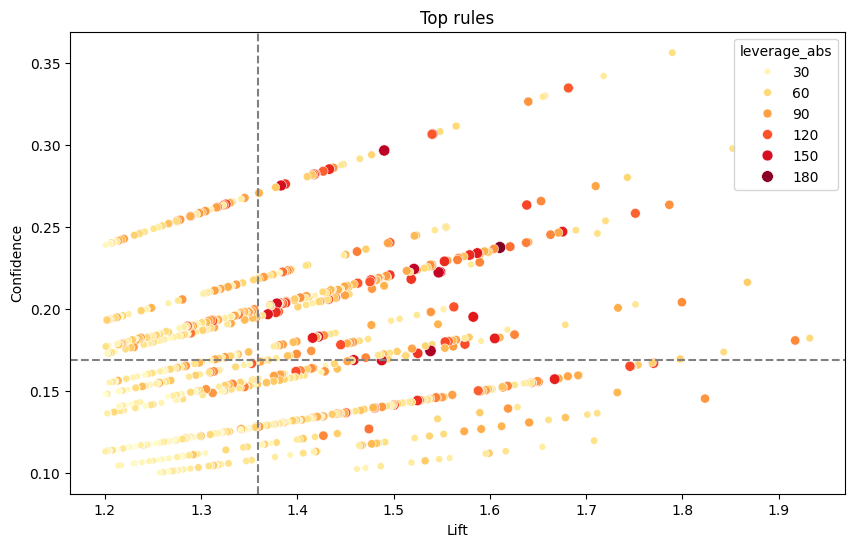

In [33]:
# khám phá tất cả rules có lift>=1.2 và confidence>=0.1

plt.figure(figsize=(10,6))
sns.scatterplot(data=top_rules,
                x='lift',
                y='confidence',
                size='leverage_abs',
                hue='leverage_abs',
                palette='YlOrRd')
plt.xlabel('Lift')
plt.ylabel('Confidence')
plt.axvline(x=top_rules['lift'].median(), color='grey', linestyle='--')
plt.axhline(y=top_rules['confidence'].median(), color='grey', linestyle='--')
plt.title('Top rules')
plt.show()

#### **Chọn ngưỡng có ý nghĩa business nhất**

1. Biểu đồ scatter cho thấy các điểm dữ liệu không rối loạn một cách lung tung, mà tạo thành nhiều trục đường chéo. **Các đường chéo này chỉ ra các nhóm combo có cùng độ phổ biến của consequents** vì trục x (lift) = trục y (confidence) / support (consequent).
2. **Chúng ta mong muốn chọn vùng có ý nghĩa nhất: lift cao, confidence cao & leverage đậm màu** (mức kì vọng tăng của đơn hàng có A&C cao nhất so với kì vọng ngẫu nhiên). Tuy nhiên, biểu đồ cho thấy không có một vùng tối ưu nhất với cả 3 kì vọng.<br>
=> Thay vào đó, có thể thấy được ba nhóm rule có tiềm năng:
  * `Nhóm rule liên kết mạnh nhưng hiếm`: **lift > 1.7 và confidence < 0.25**. Confidence thấp nhưng lift cao là do support(consequent) thấp => do đó, leverage cũng ở mức thấp, chỉ hiệu quả ở 1 nhóm khách hàng nhỏ.
  * `Nhóm rule mạnh`: **confidence > 0.3, lift = [1.6 - 1.8] và leverage > 90**. Đối với nhóm này, có thể triển khai đề xuất sản phẩm consequent khi khách hàng đã có antecedent và áp dụng ở quy mô lớn.
  * `Nhóm rule cân bằng`: ở giữa biểu đồ tập hợp khá nhiều điểm cam đậm và đỏ - nhóm này tuy không mạnh nhất nếu xét riêng trên từng rule nhưng lại cân bằng: **lift = [1.35–1.70], confidence = [0.15–0.3], với leverage > 90.**

### **6. Dán nhãn và trực quan hóa sau khi phân loại**

In [34]:
# Tối ưu hóa phân loại để giảm lượng 'Unlabeled' và phục vụ đề xuất Marketing
# Sử dụng các ngưỡng dựa trên phân phối thực tế của dữ liệu

lift_median = top_rules['lift'].median()
conf_median = top_rules['confidence'].median()

conditions = [
    (top_rules["lift"] > 1.7), # Nhóm liên kết cực mạnh (Cross-sell ưu tiên)
    (top_rules["confidence"] > 0.25) & (top_rules["lift"] > 1.2), # Nhóm hành vi phổ biến (Bundle khuyến mãi)
    (top_rules["leverage_abs"] > top_rules["leverage_abs"].quantile(0.75)) # Nhóm đóng góp doanh số thực tế cao
]

labels = [
    "Combo Liên kết Đặc thù (High Lift)",
    "Combo Hành vi Phổ biến (High Conf)",
    "Combo Đóng góp Doanh số (High Leverage)"
]

top_rules["label"] = np.select(conditions, labels, default="Nhóm Tiềm năng khác")

display(top_rules['label'].value_counts())

,count
label,
Nhóm Tiềm năng khác,665
Combo Đóng góp Doanh số (High Leverage),193
Combo Hành vi Phổ biến (High Conf),59
Combo Liên kết Đặc thù (High Lift),27


In [35]:
top_rules['label'].value_counts()


,count
label,
Nhóm Tiềm năng khác,665
Combo Đóng góp Doanh số (High Leverage),193
Combo Hành vi Phổ biến (High Conf),59
Combo Liên kết Đặc thù (High Lift),27


In [36]:
# trực quan hóa cả 3 metric: confidence, lift và support trên scatter plot
fig = px.scatter(
    top_rules,
    x='lift',
    y='confidence',
    size='leverage_abs',
    color='label',
    hover_name='combo_str',
    color_discrete_sequence=['green','grey','blue','red'],
    labels={
        'lift': 'Lift',
        'confidence': 'Confidence',
        'leverage_abs': 'Leverage'
    }
)
# set up label chỉ xuất hiện khi trỏ chuột vào bubble
fig.update_traces(
    hovertemplate=(
        "<b>%{hovertext}</b><br>"
        "Lift: %{x:.2f}<br>"
        "Confidence: %{y:.2f}<br>"
        "Leverage: %{marker.size}<extra></extra>"
    )
)

fig.show()

### **7. Kết luận và đề xuất**

**1. Phạm vi và phương pháp:**

Danh mục của công ty gồm khoảng 20.000 SKU, được phân thành 17 subcategory thuộc 5 category lớn:

* Face Care
* Hair Care
* Body Care
* Makeup
* Home & Accessories

Phân tích Market Basket được thực hiện ở cấp độ subcategory. Cấp độ này đủ chi tiết để nhận diện hành vi mua kèm, đồng thời hạn chế tình trạng dữ liệu quá phân mảnh khi phân tích trực tiếp trên SKU.

Mô hình Apriori được triển khai với các ngưỡng:


```
Minimum support: 0,1%
Minimum confidence: 10%
Minimum lift: 1,2
```
Kết quả thu được 994 association rules đáp ứng đồng thời các điều kiện trên.

**2. Các phát hiện chính:**
* Nail care products là nhóm sản phẩm được mua nhiều nhất sàn, **20% tổng số đơn hàng**. Do mức độ phổ biến nền cao, các rule có Nail care products ở consequent thường đạt confidence cao. Tuy nhiên, điều này không nhất thiết chứng minh antecedent tạo ra nhu cầu mua Nail Care.
> Confidence thể hiện xác suất đơn hàng có consequent khi antecedent đã xuất hiện, nhưng không phản ánh thứ tự khách hàng thêm sản phẩm vào giỏ và không chứng minh quan hệ nhân quả. Vì vậy, các đề xuất liên quan đến Nail Care cần được đánh giá thêm bằng lift, và leverage.
* Ngoài combo với Nail care products, các combo được mua nhiều bao gồm chăm sóc tóc, tay và cơ thể (như bath oils, body moisturizers, hand creams và shampoos and conditioners).
> Pattern này cho thấy khách hàng có xu hướng xây dựng giỏ hàng theo một routine chăm sóc tay, cơ thể và tóc, thay vì chỉ mua từng sản phẩm riêng lẻ.
* Một số combo kết hợp sản phẩm chăm sóc tóc, mặt và cơ thể với sản phẩm hỗ trợ thư giãn tại nhà có lift khoảng 1,75 đến 1,90. Tuy nhiên, support và leverage của nhiều rule vẫn thấp.
> Đây là hành vi đặc trưng của một nhóm khách hàng nhỏ yêu thích trải nghiệm self-care tại nhà, chưa phải xu hướng đủ rộng để áp dụng đại trà.

**3. Phát hiện ra 3 nhóm rules dùng để phân loại các combo sản phẩm và đề xuất hành động phù hợp:**
* `Nhóm liên kết mạnh nhưng quy mô nhỏ:` hiệu quả cao với 1 nhóm khách hàng nhỏ, riêng biệt.<br> Chiến lược đề xuất:
  * Recommendation cá nhân hóa
  * Thử nghiệm trên tập khách hàng nhỏ, không triển khai đại trà.
* `Nhóm liên kết mạnh và có khả năng mở rộng:` đặc điểm của nhóm này là lift, confidence, và leverage đều cao. <br> Chiến lược đề xuất:
  * Đề xuất consequent khi antecedent đã có trong giỏ.
  * Cross-sell trên trang sản phẩm và giỏ hàng. Tuy nhiên, để chắc chắn hơn, vẫn cần có bước pilot và A/B testing trước khi triển khai đại trà.
* `Nhóm cân bằng giữa sức mạnh và quy mô:` nhóm này khác nhóm trên ở điểm không dẫn đầu ở metric riêng lẻ nào, nhưng cả 3 chỉ số đều tương đối tốt. <br> Chiến lược đề xuất:
  * Ưu tiên vào shortlist thử nghiệm.
  * Theo dõi độ ổn định của rule qua thời gian.

**4. Hạn chế & đề xuất cải thiện:**<br>
* Ba nhóm trên mới phân loại được khoảng 13% trong tổng số 994 rules. Các điều kiện phân nhóm còn dựa trên ngưỡng thủ công, có thể chồng lấn hoặc bỏ sót nhiều rule. Do đó, hệ thống phân loại hiện tại chưa đảm bảo nguyên tắc MECE, tức là các nhóm chưa hoàn toàn loại trừ lẫn nhau và chưa bao phủ toàn bộ tập rules.
* Cải tiến phân loại bằng 1 aggregation metric từ lift, confidence, leverage để dễ so sánh và phân loại các nhóm. Có thể áp dụng clustering để khám phá các nhóm tự nhiên trước, sau đó xây dựng classifier khi đã có nhãn business rõ ràng.
* Thực hiện phân tích thêm Sequential Pattern Mining nếu dữ liệu có thêm mốc thời gian của đơn hàng: MBA chỉ cho biết A và B mua cùng nhau, không cho biết khách mua A  rồi mới mua B, Sequential Pattern Mining có thể giải quyết được bài toán thứ tự mua hàng. Từ đó, có thể triển khai recommendations dựa trên hành vi mua của khách hàng chính xác hơn.